In [ ]:
from google.colab import drive
import os

# Mount your Google Drive
drive.mount('/content/drive')

# Change the directory to your specific project folder
%cd /content/drive/MyDrive/FYP/Computing_Lab_Usage

print("Current Working Directory:", os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/FYP/Computing_Lab_Usage
Current Working Directory: /content/drive/MyDrive/FYP/Computing_Lab_Usage


Access Log Synthesis and Mapping

Generated 179 virtual workstations.


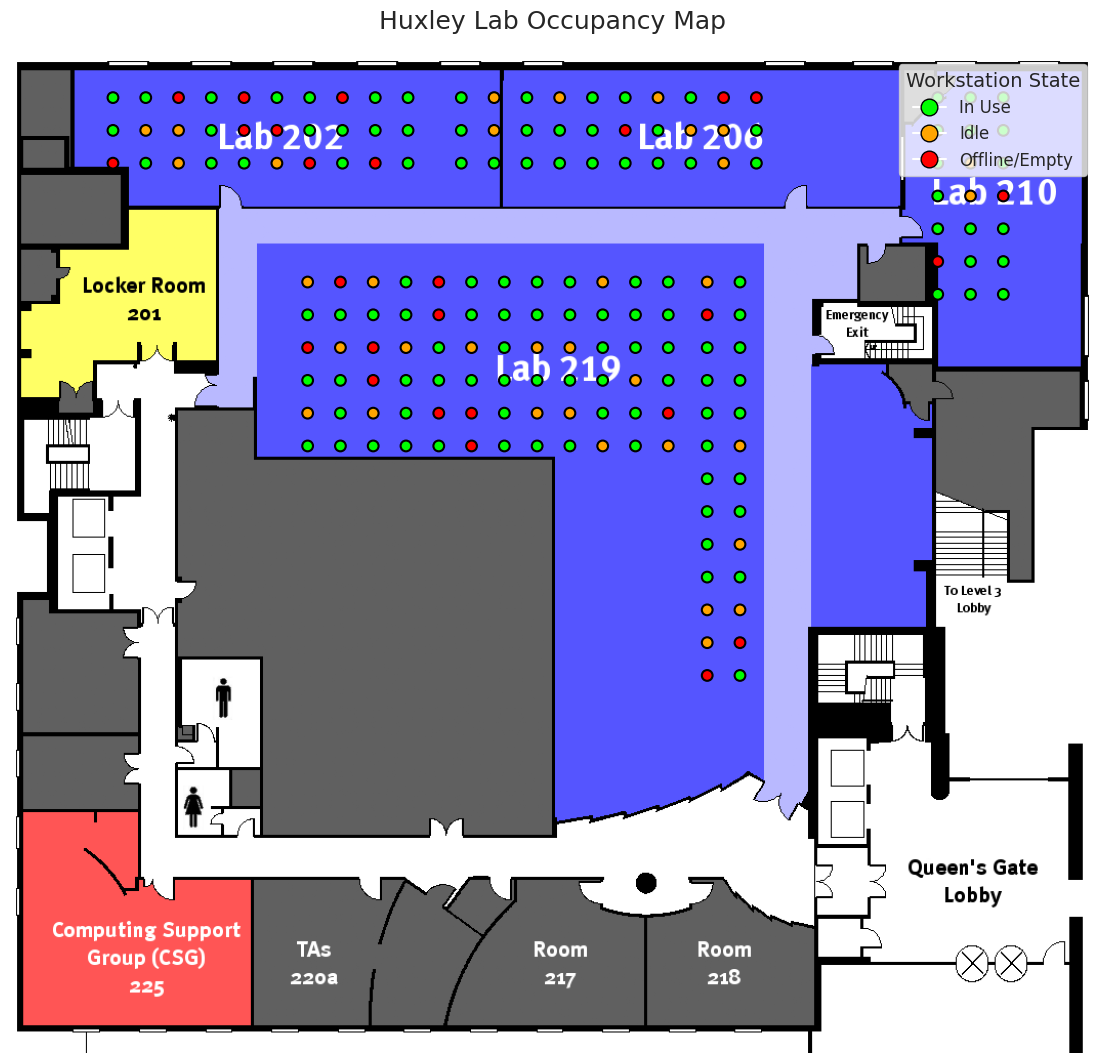

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np

# --- Configuration ---
image_path = 'floor_plan.png'

# 1. Pixel-Perfect Lab Zones (Final Tweaks for 210)
# Format: [x_min, x_max, y_min, y_max]
lab_zones = {
    'Lab_202': [100, 400, 40, 130],
    'Lab_206': [440, 750, 40, 130],
    'Lab_210': [905, 990, 40, 240],        # SHIFTED RIGHT: x_min from 885 to 905, x_max to 990
    'Lab_219_North': [290, 650, 220, 400],
    'Lab_219_East': [680, 720, 220, 630]
}

def generate_virtual_workstations(zones, spacing=32):
    """Generates a grid of (x,y) coordinates strictly within the blue lab zones."""
    workstations = []
    pc_id_counter = 1

    for zone_key, (x_min, x_max, y_min, y_max) in zones.items():
        actual_lab_name = zone_key.split('_North')[0].split('_East')[0]

        for x in range(x_min, x_max, spacing):
            for y in range(y_min, y_max, spacing):
                workstations.append({
                    'pc_id': f"{actual_lab_name}_PC{pc_id_counter:03d}",
                    'lab': actual_lab_name,
                    'x': x,
                    'y': y
                })
                pc_id_counter += 1
    return pd.DataFrame(workstations)

def synthesize_current_logs(df_workstations, time_of_day="14:00"):
    """Synthesizes mock log states based on the time of day."""
    states = ['In Use', 'Idle', 'Offline']
    probabilities = [0.70, 0.20, 0.10]

    df_workstations['state'] = np.random.choice(states, size=len(df_workstations), p=probabilities)
    df_workstations['last_active'] = pd.Timestamp(f'2024-05-15 {time_of_day}')

    return df_workstations

# --- Execution ---

# 1. Generate the map of PCs
df_map = generate_virtual_workstations(lab_zones, spacing=32)
print(f"Generated {len(df_map)} virtual workstations.")

# 2. Synthesize the log states
df_current_state = synthesize_current_logs(df_map, time_of_day="14:30")

# 3. Map states to colors
color_mapping = {
    'In Use': 'lime',
    'Idle': 'orange',
    'Offline': 'red'
}
df_current_state['color'] = df_current_state['state'].map(color_mapping)

# 4. Visualize on the Floor Plan
try:
    img = mpimg.imread(image_path)

    fig, ax = plt.subplots(figsize=(14, 14))
    ax.imshow(img)

    # Scatter plot the workstations
    ax.scatter(
        df_current_state['x'],
        df_current_state['y'],
        c=df_current_state['color'],
        s=60,
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lime', markersize=12, markeredgecolor='black', label='In Use'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=12, markeredgecolor='black', label='Idle'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=12, markeredgecolor='black', label='Offline/Empty')
    ]
    ax.legend(handles=legend_elements, loc='upper right', title="Workstation State", fontsize=12, title_fontsize=14)

    plt.title("Huxley Lab Occupancy Map", fontsize=18, pad=20)
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find '{image_path}'. Ensure the path is correct.")

Mocked access logs CSV file

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Recreate the Master List of Workstations (from your previous script)
lab_zones = {
    'Lab_202': [100, 400, 40, 130],
    'Lab_206': [440, 750, 40, 130],
    'Lab_210': [905, 990, 40, 240],
    'Lab_219_North': [290, 650, 220, 400],
    'Lab_219_East': [680, 720, 220, 630]
}

def get_workstation_ids(zones, spacing=32):
    pc_ids = []
    pc_id_counter = 1
    for zone_key, (x_min, x_max, y_min, y_max) in zones.items():
        actual_lab_name = zone_key.split('_North')[0].split('_East')[0]
        for x in range(x_min, x_max, spacing):
            for y in range(y_min, y_max, spacing):
                pc_ids.append(f"{actual_lab_name}_PC{pc_id_counter:03d}")
                pc_id_counter += 1
    return pc_ids

all_pcs = get_workstation_ids(lab_zones)
print(f"Tracking {len(all_pcs)} workstations...\n")

# 2. Define the Daily Usage Curve
def get_state_probabilities(hour):
    """
    Returns (P_In_Use, P_Idle, P_Offline) based on the time of day.
    Simulates a realistic university lab schedule.
    """
    if 0 <= hour < 7:     # Middle of the night: Basically empty
        return [0.02, 0.03, 0.95]
    elif 7 <= hour < 10:  # Morning ramp-up
        return [0.40, 0.15, 0.45]
    elif 10 <= hour < 16: # Peak hours (e.g., back-to-back labs)
        return [0.75, 0.15, 0.10]
    elif 16 <= hour < 20: # Evening wind-down
        return [0.35, 0.20, 0.45]
    else:                 # Late night stragglers (20:00 - 23:59)
        return [0.10, 0.10, 0.80]

# 3. Generate the Time-Series Data
print("Generating 24-hour log data at 15-minute intervals...")

# Start at 8:00 AM today (or pick any specific date)
start_time = pd.Timestamp('2026-04-01 00:00:00')
# Create a list of timestamps, every 15 minutes for 24 hours
time_intervals = pd.date_range(start=start_time, periods=(24 * 4), freq='15min')

log_entries = []
states = ['In Use', 'Idle', 'Offline']

for current_time in time_intervals:
    # Get the probabilities for this specific hour
    probs = get_state_probabilities(current_time.hour)

    for pc_id in all_pcs:
        # Assign a random state based on the hourly probability curve
        assigned_state = np.random.choice(states, p=probs)

        log_entries.append({
            'timestamp': current_time.strftime('%Y-%m-%d %H:%M:%S'),
            'pc_id': pc_id,
            'state': assigned_state
        })

# 4. Save to CSV
df_logs = pd.DataFrame(log_entries)
csv_filename = 'huxley_mock_access_logs.csv'
df_logs.to_csv(csv_filename, index=False)

print(f"\nSuccess! Generated {len(df_logs)} log entries.")
print(f"Saved as: {csv_filename} in your Colab environment.")
print("\n--- Data Sample ---")
print(df_logs.head())

Tracking 179 workstations...

Generating 24-hour log data at 15-minute intervals...

Success! Generated 17184 log entries.
Saved as: huxley_mock_access_logs.csv in your Colab environment.

--- Data Sample ---
             timestamp          pc_id    state
0  2026-04-01 00:00:00  Lab_202_PC001  Offline
1  2026-04-01 00:00:00  Lab_202_PC002  Offline
2  2026-04-01 00:00:00  Lab_202_PC003  Offline
3  2026-04-01 00:00:00  Lab_202_PC004  Offline
4  2026-04-01 00:00:00  Lab_202_PC005  Offline


Time Series Analysis of Mocked Access Logs

Loading access logs...
Aggregating time series data...
Generating utilisation graph...



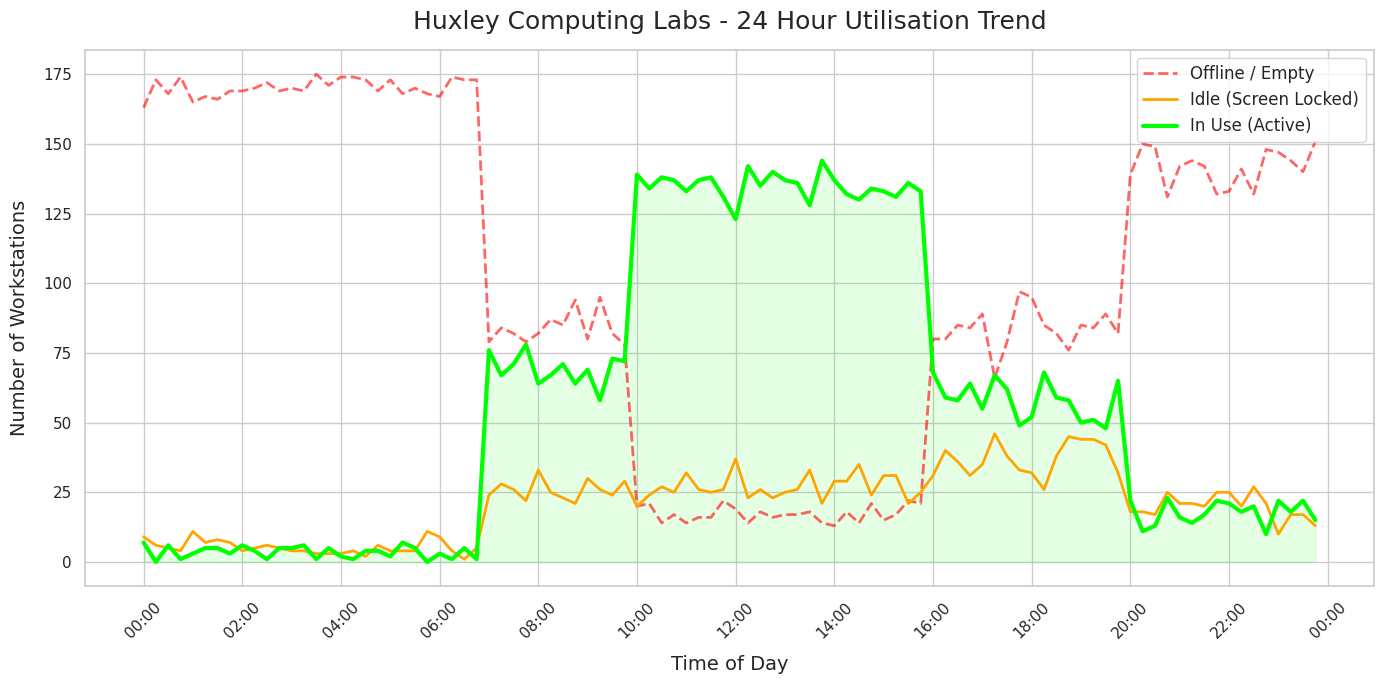


--- Quick Daily Insights ---
Peak 'In Use' workstations: 144 at 13:45
Average workstations 'In Use' during core hours (09:00 - 17:00): 115
Highest idle waste (Machines left idle): 46


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set a clean visual style for the plots
sns.set_theme(style="whitegrid")

# --- 1. Data Loading & Preparation ---
print("Loading access logs...")
df = pd.read_csv('huxley_mock_access_logs.csv')

# Crucial Step: Convert the timestamp string into a Pandas datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# --- 2. Aggregation (The Time Series Engine) ---
print("Aggregating time series data...")
# We use a pivot table to count the occurrences of each state at every unique timestamp
time_series_df = df.pivot_table(
    index='timestamp',
    columns='state',
    aggfunc='size',
    fill_value=0
)

# Ensure all columns exist just in case a state was never hit
for state in ['In Use', 'Idle', 'Offline']:
    if state not in time_series_df.columns:
        time_series_df[state] = 0

# Calculate total machines and "Total Active" (In Use + Idle)
time_series_df['Total Active'] = time_series_df['In Use'] + time_series_df['Idle']

# --- 3. Visualization ---
print("Generating utilisation graph...\n")

plt.figure(figsize=(14, 7))

# Plot the lines
plt.plot(time_series_df.index, time_series_df['Offline'], label='Offline / Empty', color='red', alpha=0.6, linewidth=2, linestyle='--')
plt.plot(time_series_df.index, time_series_df['Idle'], label='Idle (Screen Locked)', color='orange', linewidth=2)
plt.plot(time_series_df.index, time_series_df['In Use'], label='In Use (Active)', color='lime', linewidth=3)

# Formatting the X-Axis to show hours nicely
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2)) # Show tick every 2 hours
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

# Adding titles and labels
plt.title('Huxley Computing Labs - 24 Hour Utilisation Trend', fontsize=18, pad=15)
plt.xlabel('Time of Day', fontsize=14, labelpad=10)
plt.ylabel('Number of Workstations', fontsize=14, labelpad=10)

# Add a subtle background fill under the "In Use" line to make it pop
plt.fill_between(time_series_df.index, time_series_df['In Use'], color='lime', alpha=0.1)

# Add legend and adjust layout
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

# --- 4. Quick Insights ---
# Let's print out some quick automated insights from the dataframe
peak_in_use = time_series_df['In Use'].max()
peak_time = time_series_df['In Use'].idxmax().strftime('%H:%M')

print("\n--- Quick Daily Insights ---")
print(f"Peak 'In Use' workstations: {peak_in_use} at {peak_time}")
print(f"Average workstations 'In Use' during core hours (09:00 - 17:00): {int(time_series_df.between_time('09:00', '17:00')['In Use'].mean())}")
print(f"Highest idle waste (Machines left idle): {time_series_df['Idle'].max()}")

Streamlit Dashboard


In [ ]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 83.8 MB/s eta 0:00:00


Basic Streamlit Dashboard

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

st.set_page_config(page_title="Huxley Labs Dashboard", layout="wide")

st.title("Huxley Computing Labs - Live Dashboard")
st.write("This app is running directly from Google Colab!")

# Generate some dummy data just to prove it works
chart_data = pd.DataFrame(
     np.random.randn(20, 3),
     columns=['Lab 202', 'Lab 210', 'Lab 219'])

st.line_chart(chart_data)

Overwriting app.py


Running Server

In [ ]:
  import urllib

# 1. Kill any existing background Streamlit servers
!pkill -f streamlit

print("Password/Endpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

# 2. Run Streamlit with tunnel-friendly security flags
!streamlit run app.py \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    &>/content/logs.txt &

# 3. Start the tunnel
!npx localtunnel --port 8501

Password/Endpoint IP for localtunnel is: 34.44.98.176
⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://whole-planets-wash.loca.lt
^C


# New Access Logs/Lab Floorplan

Access logs with anon userIds assigned a ttl

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# 1. Recreate the Master List of Workstations
lab_zones = {
    'Lab_202': [100, 400, 40, 130],
    'Lab_206': [440, 750, 40, 130],
    'Lab_210': [905, 990, 40, 240],
    'Lab_219_North': [290, 650, 220, 400],
    'Lab_219_East': [680, 720, 220, 630]
}

def get_workstation_ids(zones, spacing=32):
    pc_ids = []
    pc_id_counter = 1
    for zone_key, (x_min, x_max, y_min, y_max) in zones.items():
        actual_lab_name = zone_key.split('_North')[0].split('_East')[0]
        for x in range(x_min, x_max, spacing):
            for y in range(y_min, y_max, spacing):
                pc_ids.append(f"{actual_lab_name}_PC{pc_id_counter:03d}")
                pc_id_counter += 1
    return pc_ids

all_pcs = get_workstation_ids(lab_zones)
print(f"Tracking {len(all_pcs)} workstations...\n")

# 2. Define the Daily Usage Curve
def get_state_probabilities(hour):
    if 0 <= hour < 7:     return [0.02, 0.03, 0.95]
    elif 7 <= hour < 10:  return [0.40, 0.15, 0.45]
    elif 10 <= hour < 16: return [0.75, 0.15, 0.10]
    elif 16 <= hour < 20: return [0.35, 0.20, 0.45]
    else:                 return [0.10, 0.10, 0.80]

# 3. Generate the Time-Series Data with TTL Logic
print("Generating 24-hour log data with Session Tracking and Anonymous Users...")

start_time = pd.Timestamp('2026-04-01 00:00:00')
time_intervals = pd.date_range(start=start_time, periods=(24 * 4), freq='15min')

log_entries = []
states = ['In Use', 'Idle', 'Offline']

# We keep track of the current state, user, and remaining time (TTL) for every PC
pc_trackers = {pc_id: {'user': 'N/A', 'ttl': 0, 'state': 'Offline'} for pc_id in all_pcs}

# The pool of anonymous users (max size = number of PCs)
available_users = set([f"AnonUser_{i:04d}" for i in range(1, len(all_pcs) + 1)])

for current_time in time_intervals:
    probs = get_state_probabilities(current_time.hour)

    for pc_id in all_pcs:
        tracker = pc_trackers[pc_id]

        # Scenario A: The user is currently in an active session (TTL > 0)
        if tracker['ttl'] > 0:
            tracker['ttl'] -= 15 # Deduct 15 minutes from their session

            # They might step away from the keyboard, so toggle between In Use/Idle
            tracker['state'] = np.random.choice(['In Use', 'Idle'], p=[0.85, 0.15])

        # Scenario B: The PC is free (TTL == 0)
        else:
            # 1. If someone was just using it, return their ID to the available pool
            if tracker['user'] != 'N/A':
                available_users.add(tracker['user'])
                tracker['user'] = 'N/A'

            # 2. Decide if someone new sits down based on the time of day
            new_state = np.random.choice(states, p=probs)

            # 3. Assign a new user and a TTL if it becomes active
            if new_state in ['In Use', 'Idle'] and len(available_users) > 0:
                # Pick a random user from the pool and remove them
                new_user = random.choice(list(available_users))
                available_users.remove(new_user)

                tracker['user'] = new_user
                tracker['state'] = new_state
                # Assign a random session length: between 15 mins and 4 hours
                tracker['ttl'] = int(np.random.choice(range(15, 255, 15))) - 15
            else:
                tracker['state'] = 'Offline'
                tracker['ttl'] = 0

        # Append the record for this 15-minute interval
        log_entries.append({
            'timestamp': current_time.strftime('%Y-%m-%d %H:%M:%S'),
            'pc_id': pc_id,
            'state': tracker['state'],
            'user_id': tracker['user'],
            'session_ttl_remaining': tracker['ttl'] if tracker['user'] != 'N/A' else 'N/A'
        })

# 4. Save to CSV
df_logs = pd.DataFrame(log_entries)
csv_filename = 'huxley_mock_access_logs_with_users.csv'
df_logs.to_csv(csv_filename, index=False)

print(f"\nSuccess! Generated {len(df_logs)} log entries.")
print(f"Saved as: {csv_filename} in your Colab environment.")
print("\n--- Data Sample ---")
print(df_logs.head(10))

Tracking 179 workstations...

Generating 24-hour log data with Session Tracking and Anonymous Users...

Success! Generated 17184 log entries.
Saved as: huxley_mock_access_logs_with_users.csv in your Colab environment.

--- Data Sample ---
             timestamp          pc_id    state        user_id  \
0  2026-04-01 00:00:00  Lab_202_PC001     Idle  AnonUser_0156   
1  2026-04-01 00:00:00  Lab_202_PC002  Offline            N/A   
2  2026-04-01 00:00:00  Lab_202_PC003  Offline            N/A   
3  2026-04-01 00:00:00  Lab_202_PC004  Offline            N/A   
4  2026-04-01 00:00:00  Lab_202_PC005  Offline            N/A   
5  2026-04-01 00:00:00  Lab_202_PC006  Offline            N/A   
6  2026-04-01 00:00:00  Lab_202_PC007  Offline            N/A   
7  2026-04-01 00:00:00  Lab_202_PC008  Offline            N/A   
8  2026-04-01 00:00:00  Lab_202_PC009  Offline            N/A   
9  2026-04-01 00:00:00  Lab_202_PC010  Offline            N/A   

  session_ttl_remaining  
0                  

Generated 179 virtual workstations.

--- Data Sample (Notice the N/A for Offline PCs) ---
           pc_id    state        user_id  session_ttl_minutes
0  Lab_202_PC001     Idle  AnonUser_0016                  136
1  Lab_202_PC002     Idle  AnonUser_0082                   62
2  Lab_202_PC003   In Use  AnonUser_0140                  225
3  Lab_202_PC004   In Use  AnonUser_0079                  236
4  Lab_202_PC005  Offline            N/A                    0
5  Lab_202_PC006   In Use  AnonUser_0043                   56
6  Lab_202_PC007     Idle  AnonUser_0030                   96
7  Lab_202_PC008   In Use  AnonUser_0032                  129
8  Lab_202_PC009   In Use  AnonUser_0133                  141
9  Lab_202_PC010   In Use  AnonUser_0078                   28
--------------------------------------------------


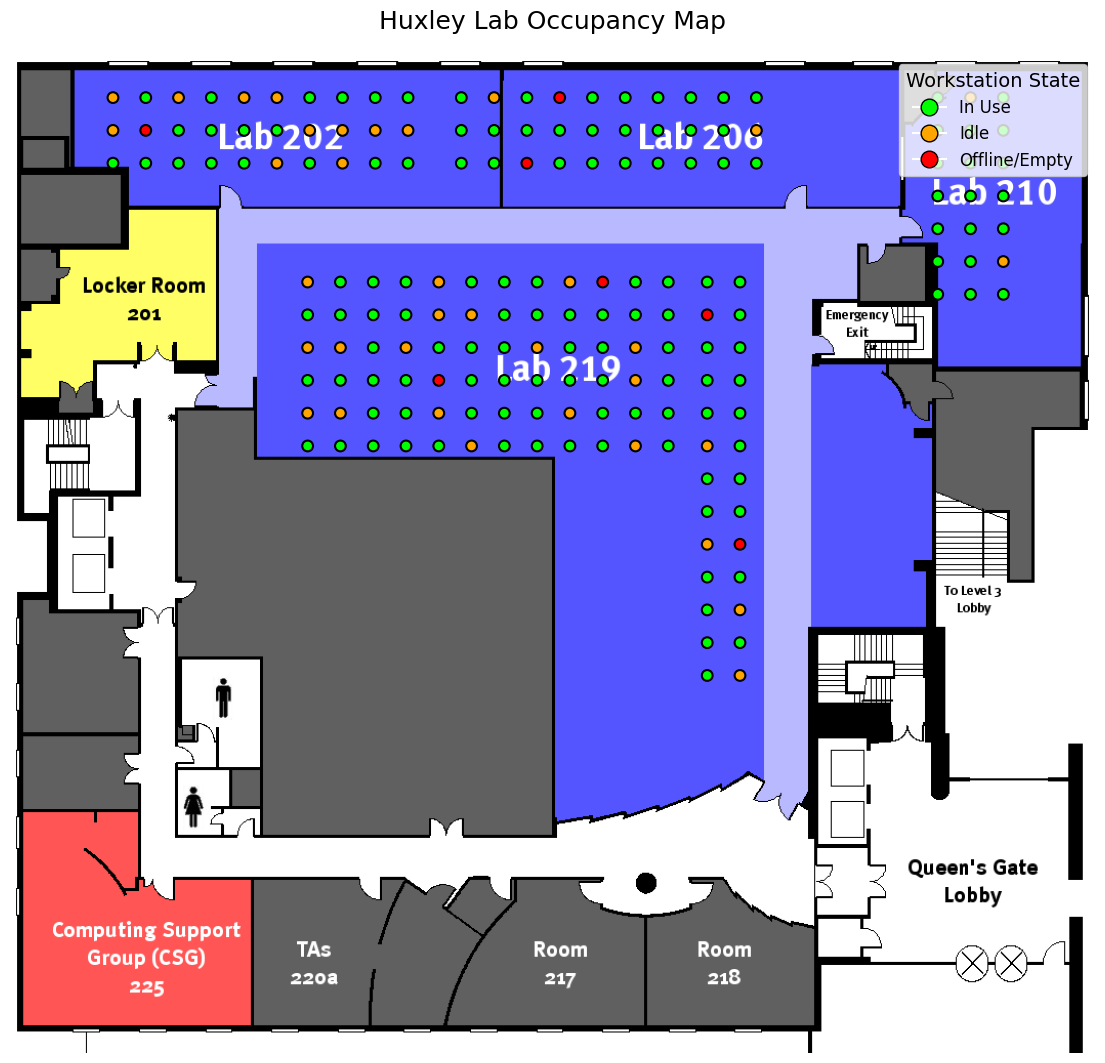

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np

# --- Configuration ---
image_path = 'floor_plan.png'

# 1. Pixel-Perfect Lab Zones (Final Tweaks for 210)
# Format: [x_min, x_max, y_min, y_max]
lab_zones = {
    'Lab_202': [100, 400, 40, 130],
    'Lab_206': [440, 750, 40, 130],
    'Lab_210': [905, 990, 40, 240],
    'Lab_219_North': [290, 650, 220, 400],
    'Lab_219_East': [680, 720, 220, 630]
}

def generate_virtual_workstations(zones, spacing=32):
    """Generates a grid of (x,y) coordinates strictly within the blue lab zones."""
    workstations = []
    pc_id_counter = 1

    for zone_key, (x_min, x_max, y_min, y_max) in zones.items():
        actual_lab_name = zone_key.split('_North')[0].split('_East')[0]

        for x in range(x_min, x_max, spacing):
            for y in range(y_min, y_max, spacing):
                workstations.append({
                    'pc_id': f"{actual_lab_name}_PC{pc_id_counter:03d}",
                    'lab': actual_lab_name,
                    'x': x,
                    'y': y
                })
                pc_id_counter += 1
    return pd.DataFrame(workstations)

def synthesize_current_logs(df_workstations, time_of_day="14:00"):
    """Synthesizes mock log states, assigns unique anonymous user IDs, and TTLs."""
    states = ['In Use', 'Idle', 'Offline']
    probabilities = [0.70, 0.20, 0.10]
    total_pcs = len(df_workstations)

    # 1. Assign the base states
    df_workstations['state'] = np.random.choice(states, size=total_pcs, p=probabilities)
    df_workstations['last_active'] = pd.Timestamp(f'2024-05-15 {time_of_day}')

    # 2. Create the Anonymous User Pool (Max size = total number of PCs)
    user_pool = [f"AnonUser_{i:04d}" for i in range(1, total_pcs + 1)]

    # 3. Identify which PCs need a user assignment
    active_mask = df_workstations['state'].isin(['In Use', 'Idle'])
    num_active = active_mask.sum()

    # 4. Sample unique users from the pool (replace=False ensures no duplicates)
    assigned_users = np.random.choice(user_pool, size=num_active, replace=False)

    # 5. Initialize the new columns
    df_workstations['user_id'] = 'N/A'
    df_workstations['session_ttl_minutes'] = 0

    # 6. Apply the users and generate a random TTL (e.g., 15 mins to 4 hours)
    df_workstations.loc[active_mask, 'user_id'] = assigned_users
    df_workstations.loc[active_mask, 'session_ttl_minutes'] = np.random.randint(15, 240, size=num_active)

    return df_workstations

# --- Execution ---

# 1. Generate the map of PCs
df_map = generate_virtual_workstations(lab_zones, spacing=32)
print(f"Generated {len(df_map)} virtual workstations.")

# 2. Synthesize the log states (Now with Users and TTLs)
df_current_state = synthesize_current_logs(df_map, time_of_day="14:30")

# --- Debug Print to Verify Logic ---
print("\n--- Data Sample (Notice the N/A for Offline PCs) ---")
print(df_current_state[['pc_id', 'state', 'user_id', 'session_ttl_minutes']].head(10))
print("-" * 50)

# 3. Map states to colors
color_mapping = {
    'In Use': 'lime',
    'Idle': 'orange',
    'Offline': 'red'
}
df_current_state['color'] = df_current_state['state'].map(color_mapping)

# 4. Visualize on the Floor Plan
try:
    img = mpimg.imread(image_path)

    fig, ax = plt.subplots(figsize=(14, 14))
    ax.imshow(img)

    # Scatter plot the workstations
    ax.scatter(
        df_current_state['x'],
        df_current_state['y'],
        c=df_current_state['color'],
        s=60,
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lime', markersize=12, markeredgecolor='black', label='In Use'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=12, markeredgecolor='black', label='Idle'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=12, markeredgecolor='black', label='Offline/Empty')
    ]
    ax.legend(handles=legend_elements, loc='upper right', title="Workstation State", fontsize=12, title_fontsize=14)

    plt.title("Huxley Lab Occupancy Map", fontsize=18, pad=20)
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find '{image_path}'. Ensure the path is correct.")